In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.services.regression_model import MusicPopularityRegressor

In [4]:
#  Carregar o dataset completo
df = pd.read_csv(project_root / "data" / "processed" / "dataset_clean.csv")
print(f"Dataset: {len(df)} musicas")

regressor = MusicPopularityRegressor(model_dir=project_root / "models")

FEATURES = [
    "danceability", "energy", "loudness_norm", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo",
]

print(f"\n Features usadas pela IA: {FEATURES}")

Dataset: 89740 musicas

 Features usadas pela IA: ['danceability', 'energy', 'loudness_norm', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']


In [11]:
np.random.seed(10)
sample = df.sample(15).reset_index(drop=True)

display(sample[["track_name", "artists", "track_genre"] + FEATURES])

,track_name,artists,track_genre,danceability,energy,loudness_norm,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,Probabilidad de Amor - Live,Daniela Darcourt;N'Klabe,salsa,0.522,0.783,0.833860,0.0347,0.4700,0.000000,0.259,0.743,90.585
1,Maldita Soledad,Salon Victoria,ska,0.579,0.830,0.801343,0.0393,0.5780,0.201000,0.186,0.937,176.159
2,Commuter,Ceephax Acid Crew,idm,0.691,0.959,0.796848,0.0369,0.0313,0.850000,0.332,0.733,125.838
3,Camelot Pollution,Ceephax Acid Crew,idm,0.623,0.857,0.717293,0.0358,0.0967,0.815000,0.093,0.897,128.715
4,Ram Sailee - Ode To My Father,Bipul Chettri,indie-pop,0.387,0.220,0.626288,0.0318,0.9460,0.000745,0.376,0.322,134.435
5,Icecoffee Season,Breakfast For Brunch,study,0.647,0.389,0.695170,0.0584,0.4400,0.829000,0.137,0.312,79.980
6,Little Things,ABBA,swedish,0.647,0.165,0.614154,0.0315,0.8940,0.001870,0.116,0.590,75.978
7,Aloha,Møme;Merryn Jeann,french,0.661,0.635,0.778869,0.0645,0.2040,0.001140,0.186,0.365,99.972
8,Convide Rutero - En Vivo,Almafuerte,heavy-metal,0.361,0.832,0.810314,0.0713,0.0219,0.000000,0.482,0.344,82.402
9,High Hopes - Live,Pink Floyd,psych-rock,0.445,0.332,0.617132,0.0265,0.4790,0.005030,0.968,0.144,74.930


In [15]:
#  A IA só vê as FEATURES
X_sample = sample[FEATURES]

# Previsão
result = regressor.predict(X_sample)

# Tabela de comparação
comparacao = pd.DataFrame({
    "Musica": sample["track_name"].str[:35],
    "Artista": sample["artists"].str[:25],
    "Genero": sample["track_genre"],
    "Real": sample["popularity"],
    "Previsto": result["predictions"],
    "Interpretacao": result["interpretations"],
})

# Comparação erro
comparacao["Erro"] = (comparacao["Real"] - comparacao["Previsto"]).abs().round(1)
comparacao["Acertou?"] = comparacao["Erro"].apply(
    lambda e : "Sim!" if e <= 10 else ("Perto" if e <= 20 else "Errou")
)

In [16]:
# Estatísticas
erro_medio = comparacao["Erro"].mean()
acertos_10 = (comparacao["Erro"] <= 10).sum()
perto_20 = (comparacao["Erro"] <= 20).sum()
total = len(comparacao)

print("Resultado FINAL")
print(f"{'=' *50}")
print(f"Erro médio: {erro_medio:.1f} pontos (de 0 a 100)")
print(f"Acertos (erro <= 10): {acertos_10}/{total} ({acertos_10/total*100:.0f})%")
print(f"Perto (erro <= 20): {perto_20}/{total} ({perto_20/total*100:.0f})%")
print(f"Erros (erro > 20): {total - perto_20}/{total} ({(total - perto_20)/total*100:.0f})%")
print(f"{'=' *50}")

Resultado FINAL
Erro médio: 17.5 pontos (de 0 a 100)
Acertos (erro <= 10): 3/15 (20)%
Perto (erro <= 20): 9/15 (60)%
Erros (erro > 20): 6/15 (40)%


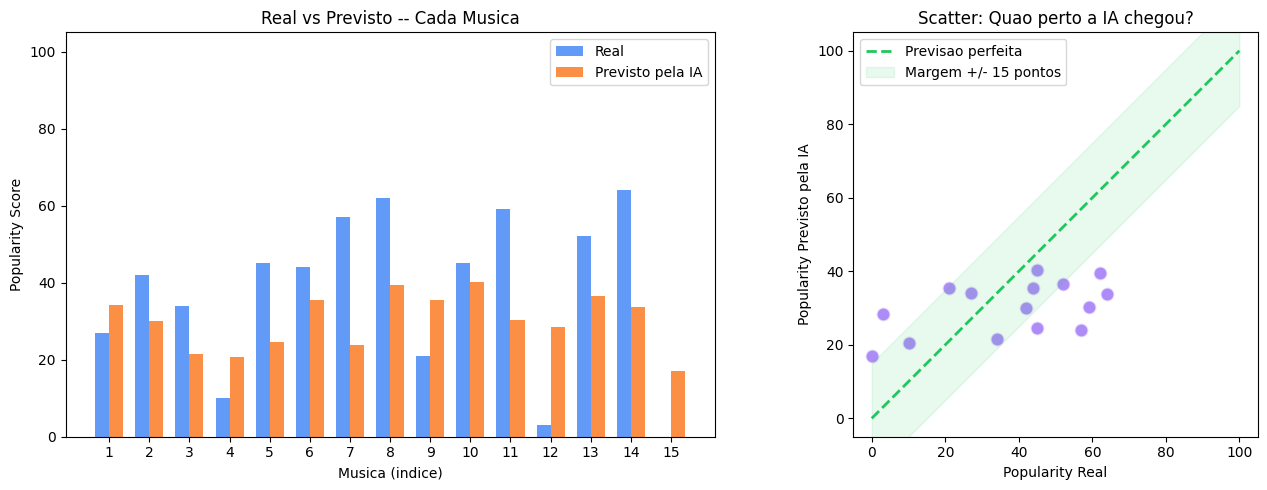


Se todos os pontos estivessem na linha verde, a IA seria perfeita!
Pontos dentro da faixa verde = previsao razoavel (erro <= 15 pontos)


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafico 1: Barras lado a lado ---
x = range(len(comparacao))
width = 0.35
bars_real = axes[0].bar([i - width/2 for i in x], comparacao["Real"], width,
                         label="Real", color="#3b82f6", alpha=0.8)
bars_pred = axes[0].bar([i + width/2 for i in x], comparacao["Previsto"], width,
                         label="Previsto pela IA", color="#f97316", alpha=0.8)

axes[0].set_xlabel("Musica (indice)")
axes[0].set_ylabel("Popularity Score")
axes[0].set_title("Real vs Previsto -- Cada Musica")
axes[0].set_xticks(x)
axes[0].set_xticklabels([str(i+1) for i in x])
axes[0].legend()
axes[0].set_ylim(0, 105)

# --- Grafico 2: Scatter (pontos) ---
axes[1].scatter(comparacao["Real"], comparacao["Previsto"],
                c="#8b5cf6", s=100, alpha=0.7, edgecolors="white", linewidth=1.5)

# Linha de previsao perfeita (diagonal)
axes[1].plot([0, 100], [0, 100], "--", color="#22c55e", linewidth=2, label="Previsao perfeita")

# Faixa de margem (+/- 15 pontos)
axes[1].fill_between([0, 100], [0-15, 100-15], [0+15, 100+15],
                      alpha=0.1, color="#22c55e", label="Margem +/- 15 pontos")

axes[1].set_xlabel("Popularity Real")
axes[1].set_ylabel("Popularity Previsto pela IA")
axes[1].set_title("Scatter: Quao perto a IA chegou?")
axes[1].set_xlim(-5, 105)
axes[1].set_ylim(-5, 105)
axes[1].legend(loc="upper left")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.savefig(project_root / "notebooks" / "regression_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSe todos os pontos estivessem na linha verde, a IA seria perfeita!")
print("Pontos dentro da faixa verde = previsao razoavel (erro <= 15 pontos)")
     